# Accountability Index Group C

## Notes 
### Codes For Cost Bases
"Pupil Basis: 1 = Enrollment plus outplaced pupils, 2 = Enrollment in district schools, 4 = Outplaced pupils"
"Pupil Basis: 1 = Enrollment plus outplaced pupils, 2 = Enrollment in district schools, 3 = Total pupils transported"

See SES at 
https://ctdatahaven.org/data-dashboard/connecticut-town-data-viewer/


SocioEconomic Data from National Center for Education Statistics https://nces.ed.gov/programs/edge/Home

In [1]:
import os
from os import path, mkdir
import glob
import re
import warnings
from datetime import datetime
import numpy as np
from scipy import stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.decomposition import PCA

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
def split_function(x):
    return x.replace(" - ", ":\n").title()

In [3]:
# Define a custom formatter function

def dollar_i(x, pos):
    return f"${x:,.0f}"
    
def dollar_k(x, pos):
    return f"${int(x/1000):,}K"
    
def dollar_k1(x, pos):
    return f"${int(x/1000):,.1f}K"

# for when data is "in thousands"
def dollar_mm(x, pos):
    return f"${int(x/1000):,}MM"

# for when data is "in thousands"
def dollar_bb(x, pos):
    return f"${(x/1000000):,.1f}B"

# for when data is "in ones" - actual million
def dollar_realmm(x, pos):
    return f"${(x/1000000):,.1f}MM"
    
# for when data is "in ones" - actual billion
def dollar_realbb(x, pos):
    return f"${(x/1000000000):,.1f}B"
    
def comma(x, pos):
    return f"{int(x):,}"

def qty_k(x, pos):
    return f"{(x/1000):,.1f}K"

def percfmt(x, pos):
    return f"{x:.1%}"

def perc2fmt(x, pos):
    return f"{x:.2%}"
    
def percifmt(x, pos):
    return f"{x:.0%}"
    
# Apply the formatter to the y-axis
dollari_formatter = ticker.FuncFormatter(dollar_i)
dollar_k_formatter = ticker.FuncFormatter(dollar_k)
dollar_k1_formatter = ticker.FuncFormatter(dollar_k1)
dollar_bb_formatter = ticker.FuncFormatter(dollar_bb)
dollar_realbb_formatter = ticker.FuncFormatter(dollar_realbb)
dollar_mm_formatter = ticker.FuncFormatter(dollar_mm)
dollar_realmm_formatter = ticker.FuncFormatter(dollar_realmm)
perc_formatter = ticker.FuncFormatter(percfmt)
perc2_formatter = ticker.FuncFormatter(perc2fmt)
perci_formatter = ticker.FuncFormatter(percifmt)

k_formatter = ticker.FuncFormatter(qty_k)
comma_formatter = ticker.FuncFormatter(comma)

In [4]:
# for plotting
rundate = datetime.now().strftime('%a %d %b %Y %H:%M:%S EDT')
software = f"Seaborn={sns.__version__}"

png_metadata = {
'Title': "Peer Educational Comparisons",
'Author': 'Joel Danke',
'Description': "Comparing Granby school performance to other schools with selected benchmarking groups",
'Creation Time': rundate,
'Software': software}

## Read data

In [5]:
# all have the "grouping" vars JSG, % w/Bachelors, etc.
totalstaff = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/totalstaff.parquet')
function_exp = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/expenditures.parquet')
accountability = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/accountability.parquet')

# just district & year, also Category is used to split
school_accountability = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/accountability_schools.parquet')

In [6]:
# income data
income_vars =  ['District', 'Fiscal Year End', 'Size of adjusted gross income', 'Income Per Taxpayer', 'Equalized Net Grand List Per Taxpayer',
                'Real Income Per Taxpayer', 'Real Disposable Income Per Taxpayer', 'Real Equalized Net Grand List Per Taxpayer',
                'Debt Service Share Of Budget', 'Education Share Of Budget', 'Education Share Of Eq Grand List', 'Education Share Of Income', 'Taxpayers']

district_total_income = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_incomes.parquet')[income_vars]
district_total_income = district_total_income[district_total_income['Size of adjusted gross income'] == 'Total'].copy()

# re-use 2022 as 2023
district_total_2023 = district_total_income[district_total_income['Fiscal Year End'] == 2023].copy()
district_total_2023['Fiscal Year End'] = district_total_2023['Fiscal Year End'] + 1
district_total_income = pd.concat([district_total_income, district_total_2023], ignore_index=True)

# make school year as the one that starts the next fiscal year
district_total_income['School Year'] = (district_total_income['Fiscal Year End'] + 1).astype('str')

In [7]:
# population (has extra year from municipal grand list
popdf_districts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/population_district.parquet')
# as string to join
popdf_districts['School Year'] = popdf_districts['Year'].astype('str')
popdf_districts.drop(columns=['Year'], inplace=True)

## Filter data to "Peer Group"
Dropping Southington - it is just too large!

In [8]:
# peer selection
PEERVAR = "finproj"
peer_condition = f"{PEERVAR} > 0"

PEERTEXT = "DRG C"

#make directory if needed
try:
    mkdir(f"./charts/peer_districts/{PEERVAR}")
except FileExistsError:
    pass
#make directory if needed
try:
    mkdir(f"./charts/staffing/{PEERVAR}")
except FileExistsError:
    pass
    
try:
    mkdir(f"./charts/accountability/{PEERVAR}")
except FileExistsError:
    pass

### Staffing
This includes regional schools that are 7-12 or 9-12 only. It might be "more fair" to include only K-12 institutions.

In [9]:
# ignore elementary districts
totalstaff['SpecialEd Share Of Ed'] = (totalstaff['SpecialEd'] / (totalstaff['Educational'] + totalstaff['SpecialEd']))
peerstaff = totalstaff[(totalstaff['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                       (totalstaff['High Grade'] == 12) & (totalstaff['Year'] > '2009')]\
            .query(peer_condition).copy()

peerstaff = peerstaff[~peerstaff['District'].str.startswith('Southington')]
peerstaff.sort_values(by=['Granby', 'Year'], ascending=[False, True], inplace=True)

### Expenditures

#### Object Expenditures
Used as an estimate of overhead costs. Salaries are not subdivided by instructional, admin, custodial.

**Purchased Services** – Services rendered by organizations or
personnel not on the payroll of the school district. Although
a product may or may not result from the transaction, the
primary reason for the purchase is the service provided.  
**Supplies** – Items that are consumed, are worn out, or have
deteriorated through use or items that lose their identity
through fabrication or incorporation into different or more
complex units or substances. Includes, for example, 
instructional supplies such as textbooks, office supplies,
electricity, and fuel.  
**Property** – Purchases of equipment, furniture, equipment,
and for minor school construction projects such as for roof
replacement, energy conservation, or updates to comply
with building codes.  
**Other** – Expenditures not included in the other objects.  
**Tuition** – Line shown if greater than 5 applicable pupils.
Reimbursements to other educational entities for
instructional services to students residing within the legal
boundaries of the paying school district.


**Budget Book**  
**Largest Benefit Increase + \$346K**: Board's contribution to the Granby Health Benefit Fund for employee medical/dental insurance. The budget includes a slight premium increase, as well as census changes. Additionally, **commencing in FY27,** additional OPEB contributions are being paid by the Board of Education to meet the Actuarily Determined Contribution (ADC).  

**Purchased Services**:  
**Educational Services \$595K**: Includes funds for services including copiers, substitutes, curriculum development activities, **school resource officer benefits**, purchased instructional services for virtual classes, etc.   
**Support Services \$540K**: Includes funds for health service and physician fee contracted services. Contracted nursing services will increase 5% in FY27.  
**Support Services \$262K**: Includes funds for special education support services for evaluation services required by law. This budget also supports the Alternative Learning Center at the middle school/high school and training for teachers to deliver specialized reading instruction. The increase reflects **higher School Resource Officer benefits**, increased subsitute service rates, and hazardous waste disposal costs for science laboratories.  
**P/L Insurance \$120K**: Includes funds for property, auto, legal liability and cyber insurance.  
**Legal Fees \$69K**: Includes funds for legal fees associated with legal compliance, employee relations and grievances, internal investigations, risk management and defense, complex matters surrounding education, as well as collective bargaining, complex special education matters and due process hearings.

#### Functional Expenditures

**Instruction**  
Activities dealing directly with the interaction between teachers and students. Teaching may be provided for students in a school classroom or in another location.  

**Support services – students**  
Activities providing student support services designed to assess and improve the well-being of students and to supplement the teaching process. This includes guidance, social, and health services.  

**Support Services – instruction**  
Activities assisting the instructional staff with the content and process of providing learning experiences for students not reported as Improving Instruction or Library and media service.  

**Support Services – general administration**  
Activities of the board of education and the superintendent's office.  

**Support Services – school-based administration**  
Activities concerned with the administrative responsibility of directing and managing the operation of a school, such as the principal's office.  

**Central and other support services**  
Activities that support other administrative and instructional functions, including fiscal services, human resources, planning, and administrative information technology, and other support services not included elsewhere.  

**Operation and maintenance of plant**  
Activities concerned with keeping the physical plant open, comfortable and safe for use and with keeping the grounds, buildings, and equipment in effective working condition and state of repair.  

**Student transportation services**
Activities providing transportation to and from home, for field trips, and for athletic activities.  

**Food services**  
Activities concerned with providing food to students and staff in a school or school district. This report includes only expenditures from local funds used to cover an operating deficit in the food service program, where revenue from child nutrition grants, fees, and other sources is insufficient to cover all expenses.

**Enterprise operations**  
Activities for enterprise operations, i.e. activities that are financed and operated in a manner similar to private business enterprises, for example a school bookstore. Also includes athletics, bands, dramatics, and any school activity paid by local appropriations. Does not include any student activity funds.

**Minor school construction**  
Activities concerned with minor school construction projects, such as for roof replacement, energy conservation, or updates to comply with building codes. (Applies to years earlier than 2019-20 only.)  

In [10]:
# filter to remove non-essential schools, functions
peer_expenditures = function_exp[(function_exp['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                (~function_exp['Function'].isin(['Minor school construction', 'Enterprise operations', 'Food services'])) &
                                (function_exp['High Grade'] == 12)]\
                    .query(peer_condition).copy()

# not sure this is used
peer_ave = peer_expenditures.groupby(['Function', 'Year'])['PPE Growth'].median().reset_index().rename(columns={'PPE Growth': 'Median PPE Growth'})
peer_expenditures = peer_expenditures.merge(peer_ave, how='left', on=['Function', 'Year'])

peer_expenditures = peer_expenditures[~peer_expenditures['District'].str.startswith('Southington')]
peer_expenditures['School Year'] = peer_expenditures['Year'].str.slice(0,4)
peer_expenditures.sort_values(by=['School Year', 'Function', 'District'], inplace=True)

### Accountability

**NO Southington**  
**No Covid Years**  

Connecticut's Next Generation Accountability reports for 2017-18 didn't show science scores because the state administered a field test (Smarter Science Field Test) instead of the regular CMT/CAPT science tests. 

In 2017-18, Connecticut's Next Generation Accountability system integrated Smarter Balanced tests (ELA/Math) with the new Next Generation Science Standards (NGSS) assessment, a field test/pilot for Grades 5, 8, and 11, aligning science with modern standards and transitioning from older science measures to a more comprehensive, standards-based approach for college/career readiness. Schools used multiple indicators, including these assessments, to show progress. 

In [11]:
# remove nonessential schools
peer_accountability = accountability[(accountability['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                     (accountability['High Grade'] == 12)]\
                     .query(peer_condition).copy()

peer_accountability = peer_accountability[~peer_accountability['District'].str.startswith('Southington')]

peer_accountability.sort_values(by=['Granby', 'Year'], ascending=[False, True], inplace=True)
peer_accountability['School Year'] = peer_accountability['Year'].str.slice(0,4).astype('int')

## Combine accountability, expenditures, staffing

Select columns to avoid duplicates.

In [12]:
# Avoid duplicating clustering variables when getting staff data
peerdrop = [x for x in peerstaff.columns if ((x in peer_expenditures.columns) & (x not in ['Year', 'District']))]

# For accountability index select only necessary variables
values = ['Math PI', 'Math Growth', 'ELA PI', 'ELA Growth', 'Science PI',
          'CCR - Taking Courses', 'CCR - Passing Exams', 'Postsecondary Entrance', 
          'On-track to HS Graduation', '4-yr Graduation', 'Chronic Absenteeism',
          'Physical Fitness', 'Arts Access', 'Accountability Index']

high_need = ['ELA PI - High Needs',  'ELA Growth - High Needs', 
             'Math PI - High Needs', 'Math Growth - High Needs',
             'Science PI - High Needs', 'Chronic Absenteeism - High Needs', '6-yr Graduation - High Needs']

### Total Expenditures

In [13]:
# filter to only one Function per district per year
# get other type of expenditures for reporting only

_benefits = peer_expenditures[peer_expenditures['Function'] == 'Employee Benefits'][['Year', 'District', 'PPE', 'Expenditures', 'Real Expenditures']]\
                             .rename(columns={'PPE': 'Benefits Per Student', 'Expenditures': 'Benefits', 'Real Expenditures': 'Real Benefits'}).copy()

_services = peer_expenditures[peer_expenditures['Function'] == 'Services And Supplies'][['Year', 'District', 'PPE', 'Real PPE']]\
                             .rename(columns={'PPE': 'Purchased Services Per Student', 'Real PPE': 'Real Purchased Services Per Student'}).copy()

# ONLY "total" expenditures, accountability index
peer_combined = peer_expenditures[peer_expenditures['Function'] == 'Total']\
                .merge(_benefits,  how='left', on=['Year', 'District'])\
                .merge(_services,  how='left', on=['Year', 'District'])\
                .merge(peer_accountability[['Year', 'District'] + values], how='left', on=['Year', 'District'])\
                .merge(peerstaff.drop(columns=['Town', 'Low Grade', 'High Grade','Organization Type', 'Type', 'Granby', 'Pupils', 'Size'] + peerdrop),
                                            how='left', on=['Year', 'District'])\
                .merge(popdf_districts, how='left', on=['School Year', 'District'])\
                .merge(district_total_income, how='left', on=['School Year', 'District'])

peer_combined['% Student'] = peer_combined['Enrollment'] / peer_combined['Population']
peer_combined['Expenditures Per Student'] = peer_combined['Expenditures'] / peer_combined['Enrollment']
peer_combined['Real Expenditures Per Student'] = peer_combined['Real Expenditures'] / peer_combined['Enrollment']

peer_combined['Benefits Per FTE'] = peer_combined['Benefits'] / peer_combined['FTE Count']
peer_combined['Real Benefits Per FTE'] = peer_combined['Real Benefits'] / peer_combined['FTE Count']

peer_combined['Non-Instruction $ Per Student'] = peer_combined['Expenditures Per Student'] - peer_combined['Instruction $ Per Student']
peer_combined['Real Non-Instruction $ Per Student'] = peer_combined['Real Expenditures Per Student'] - peer_combined['Real Instruction $ Per Student']

peer_combined['Payroll Less Instruction Per Student'] = peer_combined['Payroll Per Student'] - peer_combined['Instruction $ Per Student']
peer_combined['Real Payroll Less Instruction Per Student'] = peer_combined['Real Payroll Per Student'] - peer_combined['Real Instruction $ Per Student']

### Instructional Expenditures

In [14]:
# ONLY "instructional" expenditures only
peer_instruction = peer_expenditures[peer_expenditures['Function'] == 'Instruction']\
                   .merge(peer_accountability[['Year', 'District'] + values], how='left', on=['Year', 'District'])\
                   .merge(peerstaff.drop(columns=['Town', 'Low Grade', 'High Grade','Organization Type', 'Type', 'Granby', 'Pupils', 'Size'] + peerdrop),
                                            how='left', on=['Year', 'District'])

peer_instruction.sort_values(by=['District', 'Year'], inplace=True)
peer_instruction.reset_index(inplace=True, drop=True)

### Derivations

In [15]:
# help w/plotting styles
peerstaff[PEERVAR] = peerstaff[PEERVAR].where(~peerstaff['District'].str.startswith('Region'), 3)
peer_expenditures[PEERVAR] = peer_expenditures[PEERVAR].where(~peer_expenditures['District'].str.startswith('Region'), 3)
peer_accountability[PEERVAR] = peer_accountability[PEERVAR].where(~peer_accountability['District'].str.startswith('Region'), 3)
peer_combined[PEERVAR] = peer_combined[PEERVAR].where(~peer_combined['District'].str.startswith('Region'), 3)
peer_instruction[PEERVAR] = peer_instruction[PEERVAR].where(~peer_instruction['District'].str.startswith('Region'), 3)

### Detailed Accountability

In [16]:
distcols = list(peer_accountability.drop(columns=values+high_need).columns)
distcols = [x for x in distcols if ((x.find('Progress') < 0) & (x.find(' Grade') < 0))]

school_accountability = school_accountability.merge(peer_accountability[distcols].drop(columns=['School Year']), how='inner', on=['District', 'Year'])
district_accountability = school_accountability.query('Category == "District"')
school_accountability = school_accountability.query('Category == "School"')

In [17]:
district_accountability.shape, school_accountability.shape

((6586, 46), (29008, 46))

## Peer Overview

In [18]:
idx = pd.IndexSlice
slice_ = idx[idx["Granby School District"], idx[:]]

_d = peer_combined.query('Year == "2024-25"')[['District', 'Enrollment', 'Accountability Index',
                                               'High Needs Students Share of Enrollment', 'Students w/ Disabilities Share of Enrollment',
                                               'Instruction $ Per Student', 'Math PI', 'Math Growth', 'ELA PI', 'ELA Growth', 'Science PI',
                                               'CCR - Taking Courses', 'CCR - Passing Exams', 'Postsecondary Entrance',]]\
        .rename(columns = {'High Needs Students Share of Enrollment': 'High Needs %',
                          'Students w/ Disabilities Share of Enrollment': 'w/Disability %', 'Postsecondary Entrance': '2/4yr Post HS',
                          'CCR - Taking Courses': 'CCR (Courses)', 'CCR - Passing Exams': 'CCR (Exams)'})\
        .sort_values('Instruction $ Per Student').copy()

_d.set_index('District', inplace=True)
_d.style.format({x: "{:,.1f}" for x in ["Accountability Index", 'Math PI', 'Math Growth', 'ELA PI', 'ELA Growth', 'Science PI', 'CCR (Courses)', 'CCR (Exams)', '2/4yr Post HS']} | 
                  { x: "${:,.0f}" for x in ["'Payroll Less Instruction Per Student'", 'Instruction $ Per Student', 'Non-Instruction $ Per Student', 'Payroll Less Instruction Per Student',
                                            'Non-Instruction $ Per Student', 'Purchased Services Per Student', 'Equalized Net Grand List Per Taxpayer', 'Income Per Taxpayer']} |
                  { x: "{:,.1%}" for x in ['Education Share Of Income', 'w/Disability %', 'High Needs %']} |
                  {'Enrollment': "{:,.0f}"} )\
    .set_properties(**{"background-color": "#ffffb3", 'font-weight' : 'bold'}, subset=slice_)\
    .set_caption("2024-2025 School Year Key Stats")\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


,Enrollment,Accountability Index,High Needs %,w/Disability %,Instruction $ Per Student,Math PI,Math Growth,ELA PI,ELA Growth,Science PI,CCR (Courses),CCR (Exams),2/4yr Post HS
District,,,,,,,,,,,,,
Somers School District,"1,347",79.5,20.8%,15.3%,"$11,380",86.5,62.3,92.8,61.5,91.7,100.0,75.2,100.0
North Haven School District,"3,214",79.2,34.8%,14.7%,"$12,003",94.8,63.6,98.7,61.9,95.3,100.0,80.8,100.0
Ellington School District,"2,526",80.0,35.7%,17.7%,"$12,242",98.4,66.1,98.9,59.8,96.8,100.0,83.7,100.0
Regional School District 10,"2,140",80.6,29.2%,16.9%,"$12,868",92.1,60.0,96.2,64.8,95.9,100.0,86.8,100.0
Tolland School District,"2,144",79.2,30.8%,17.4%,"$12,912",97.2,70.0,97.9,59.9,88.6,89.5,63.9,100.0
Bolton School District,688,79.5,29.5%,11.2%,"$13,079",93.7,67.3,95.7,61.8,95.0,100.0,93.9,100.0
Newtown School District,"3,924",80.0,27.4%,15.6%,"$13,327",98.8,71.9,100.0,67.0,93.5,100.0,78.5,100.0
Granby School District,"1,709",82.8,30.7%,17.5%,"$13,396",91.4,75.0,97.9,62.9,100.0,100.0,100.0,100.0
New Fairfield School District,"2,123",80.4,33.6%,18.8%,"$13,521",95.3,67.0,97.5,65.2,96.9,100.0,74.1,100.0


In [19]:
idx = pd.IndexSlice
slice_ = idx[idx["Granby School District"], idx[:]]

_d = peer_combined.query('Year == "2024-25"')[['District', 'Equalized Net Grand List Per Taxpayer', 'Income Per Taxpayer',
                                               'Education Share Of Income', 'Expenditures', 'Enrollment', 'Accountability Index',
                                              'High Needs Students Share of Enrollment', 'Students w/ Disabilities Share of Enrollment',
                                               'Expenditures Per Student', 'Instruction $ Per Student', 'Non-Instruction $ Per Student',
                                               'Payroll Less Instruction Per Student', 'Purchased Services Per Student']]\
        .rename(columns = {'High Needs Students Share of Enrollment': 'High Needs %',
                          'Students w/ Disabilities Share of Enrollment': 'w/Disability %',})\
    .sort_values('Instruction $ Per Student').copy()


_d.drop(columns=['Expenditures Per Student'], inplace=True)

_d.set_index('District', inplace=True)
_d.style.format({"Accountability Index": "{:,.1f}"} | { "Expenditures": lambda x: f"${(x/1000000):,.1f}MM"} |
                  { x: "${:,.0f}" for x in ["'Payroll Less Instruction Per Student'", 'Instruction $ Per Student', 'Non-Instruction $ Per Student', 'Payroll Less Instruction Per Student',
                                            'Non-Instruction $ Per Student', 'Purchased Services Per Student', 'Equalized Net Grand List Per Taxpayer', 'Income Per Taxpayer']} |
                  { x: "{:,.1%}" for x in ['Education Share Of Income', 'w/Disability %', 'High Needs %']} |
                  {'Enrollment': "{:,.0f}"} )\
    .set_properties(**{"background-color": "#ffffb3", 'font-weight' : 'bold'}, subset=slice_)\
    .set_caption("2024-2025 School Year Key Stats")\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


,Equalized Net Grand List Per Taxpayer,Income Per Taxpayer,Education Share Of Income,Expenditures,Enrollment,Accountability Index,High Needs %,w/Disability %,Instruction $ Per Student,Non-Instruction $ Per Student,Payroll Less Instruction Per Student,Purchased Services Per Student
District,,,,,,,,,,,,
Somers School District,"$250,550","$88,336",5.1%,$29.8MM,"1,347",79.5,20.8%,15.3%,"$11,380","$10,716","$6,516","$3,513"
North Haven School District,"$311,017","$82,104",4.5%,$68.3MM,"3,214",79.2,34.8%,14.7%,"$12,003","$9,263","$3,920","$4,543"
Ellington School District,"$229,563","$78,750",5.4%,$53.0MM,"2,526",80.0,35.7%,17.7%,"$12,242","$8,747","$4,606","$3,582"
Regional School District 10,"$256,361","$84,215",4.3%,$46.1MM,"2,140",80.6,29.2%,16.9%,"$12,868","$8,659","$3,344","$3,970"
Tolland School District,"$218,339","$90,161",5.0%,$46.0MM,"2,144",79.2,30.8%,17.4%,"$12,912","$8,522","$3,439","$4,084"
Bolton School District,"$220,992","$78,999",5.8%,$16.9MM,688,79.5,29.5%,11.2%,"$13,079","$11,460","$6,367","$4,501"
Newtown School District,"$329,172","$110,262",4.3%,$92.0MM,"3,924",80.0,27.4%,15.6%,"$13,327","$10,123","$5,089","$3,821"
Granby School District,"$236,361","$91,622",5.1%,$39.0MM,"1,709",82.8,30.7%,17.5%,"$13,396","$9,444","$3,689","$4,373"
New Fairfield School District,"$340,232","$98,581",4.6%,$51.7MM,"2,123",80.4,33.6%,18.8%,"$13,521","$10,836","$5,464","$4,468"


In [20]:
# Largest YoY growth
peer_expenditures[peer_expenditures['Function'] == 'Instruction'].groupby('District')['Real PPE Growth'].max().sort_values()

District
Regional School District 18      1.010330
Litchfield School District       1.033056
Tolland School District          1.036862
New Fairfield School District    1.057530
Regional School District 10      1.063621
Bolton School District           1.071305
Suffield School District         1.080043
Regional School District 14      1.093620
North Haven School District      1.097471
Newtown School District          1.098590
Ellington School District        1.115517
Stonington School District       1.122930
Somers School District           1.124167
Regional School District 17      1.129840
East Lyme School District        1.136177
Colchester School District       1.137678
Granby School District           1.147319
East Granby School District      1.173097
Regional School District 13      1.220624
Regional School District 06      1.358367
Name: Real PPE Growth, dtype: float64

## Color Scheme

In [21]:
# color scheme
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in peer_combined['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

peer_cols = {3: (0.19, 0.27, 0.57, .4),
             2: 'black',
             1: (0.529, 0.808, 0.922, .4)}

flag_cols = {0:(0.69, 0.77, 0.87, .4), 1:'black'}

## Accountability Index

### NO COVID YEARS!

Granby does not have Progress Toward English Proficiency (ESL)

Connecticut's Next Generation Accountability reports for 2017-18 didn't show science scores because the state administered a field test (Smarter Science Field Test) instead of the regular CMT/CAPT science tests. 

In 2017-18, Connecticut's Next Generation Accountability system integrated Smarter Balanced tests (ELA/Math) with the new Next Generation Science Standards (NGSS) assessment, a field test/pilot for Grades 5, 8, and 11, aligning science with modern standards and transitioning from older science measures to a more comprehensive, standards-based approach for college/career readiness. Schools used multiple indicators, including these assessments, to show progress. 

### District: Overall

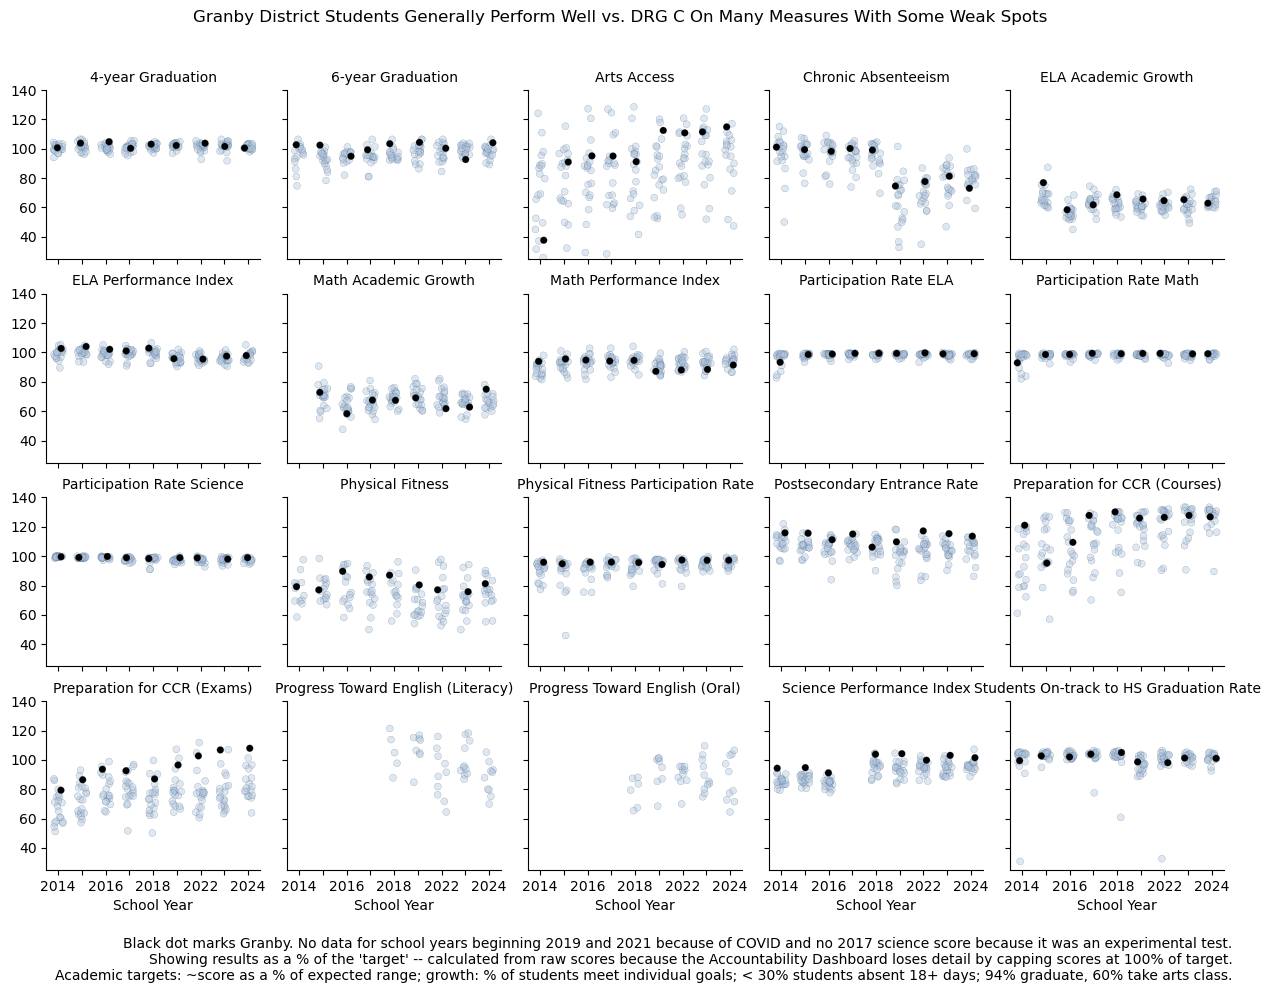

In [22]:
g = sns.catplot(data=district_accountability.query('Needs == "All"')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip', jitter=.2,
                col='Indicator', col_wrap=5, legend=False,
                height=2.5, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=25)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle(f"Granby District Students Generally Perform Well vs. {PEERTEXT} On Many Measures With Some Weak Spots")
plt.tight_layout()
plt.subplots_adjust(top=.9, bottom=0.12)
line1 = "Black dot marks Granby. No data for school years beginning 2019 and 2021 because of COVID and no 2017 science score because it was an experimental test.\n"
line2 = "Showing results as a % of the 'target' -- calculated from raw scores because the Accountability Dashboard loses detail by capping scores at 100% of target.\n"
line3 = "Academic targets: ~score as a % of expected range; growth: % of students meet individual goals; < 30% students absent 18+ days; 94% graduate, 60% take arts class."
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)

plt.savefig(f"./charts/accountability/{PEERVAR}/district_overall.png", dpi=200, metadata=png_metadata)

plt.show()

### District: Not High Needs

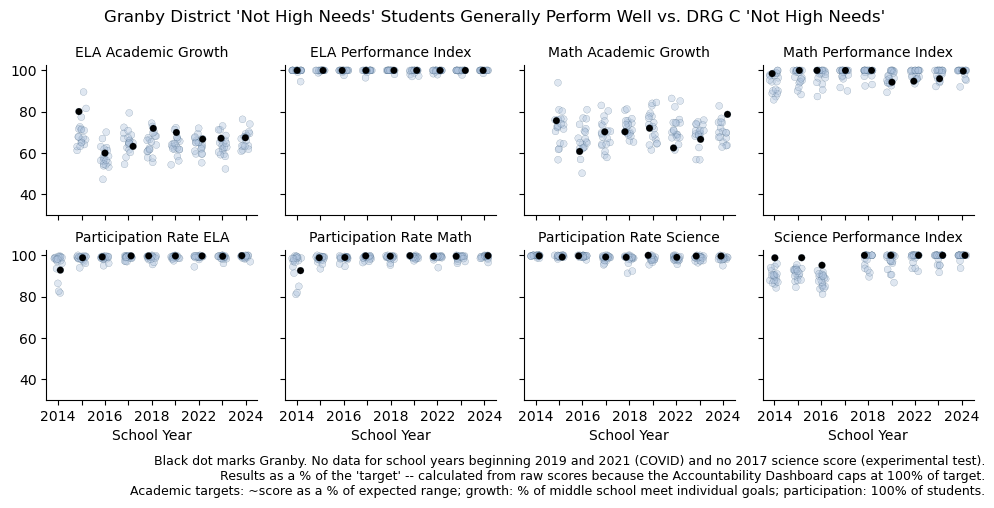

In [23]:
g = sns.catplot(data=district_accountability.query('Needs == "Not High Needs"')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip', jitter=.2,
                col='Indicator', col_wrap=4, legend=False,
                height=2.5, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=30)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle(f"Granby District 'Not High Needs' Students Generally Perform Well vs. {PEERTEXT} 'Not High Needs'")
plt.tight_layout()
plt.subplots_adjust(top=.87, bottom=0.2)
line1 = "Black dot marks Granby. No data for school years beginning 2019 and 2021 (COVID) and no 2017 science score (experimental test).\n"
line2 = "Results as a % of the 'target' -- calculated from raw scores because the Accountability Dashboard caps at 100% of target.\n"
line3 = "Academic targets: ~score as a % of expected range; growth: % of middle school meet individual goals; participation: 100% of students."
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/accountability/{PEERVAR}/district_not_high_needs.png", dpi=200, metadata=png_metadata)

plt.show()

### District: High Needs

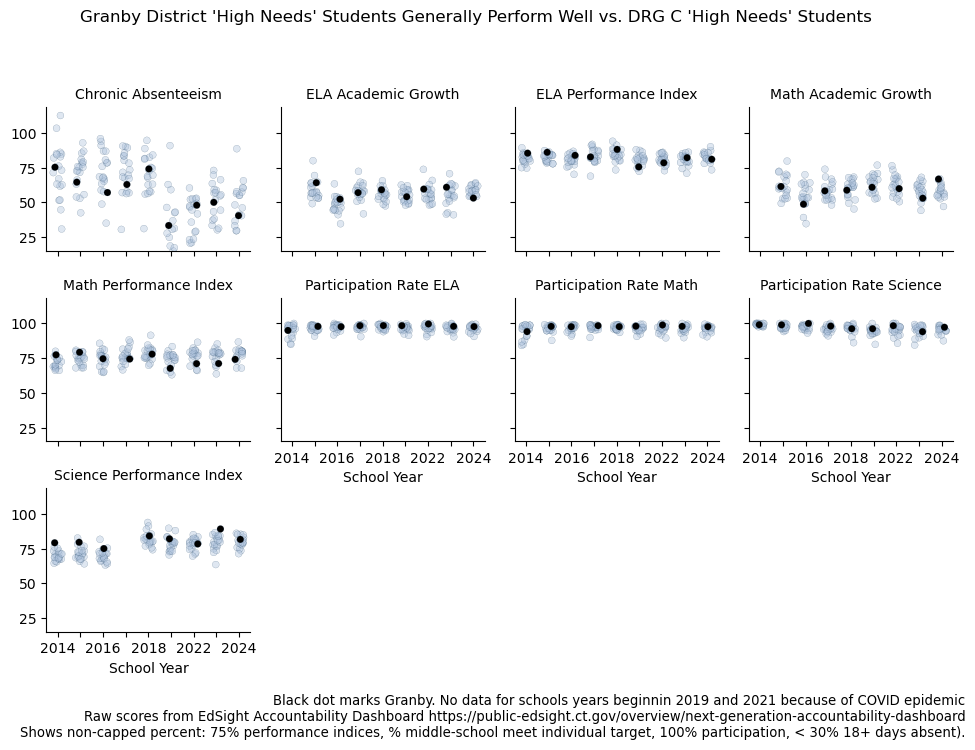

In [24]:
g = sns.catplot(data=district_accountability.query('Needs == "High Needs"')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip', jitter=.2,
                col='Indicator', col_wrap=4, legend=False,
                height=2.5, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=15)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle(f"Granby District 'High Needs' Students Generally Perform Well vs. {PEERTEXT} 'High Needs' Students")
plt.subplots_adjust(top=.85, bottom=0.15)
line1 = "Black dot marks Granby. No data for schools years beginnin 2019 and 2021 because of COVID epidemic\n"
line2 = "Raw scores from EdSight Accountability Dashboard https://public-edsight.ct.gov/overview/next-generation-accountability-dashboard\n"
line3 = "Shows non-capped percent: 75% performance indices, % middle-school meet individual target, 100% participation, < 30% 18+ days absent)."
g.fig.text(.99, .01, line1 + line2 + line3 , ha='right', fontsize=9.5)

plt.savefig(f"./charts/accountability/{PEERVAR}/district_high_needs.png", dpi=200, metadata=png_metadata)

plt.show()

### High School: Overall

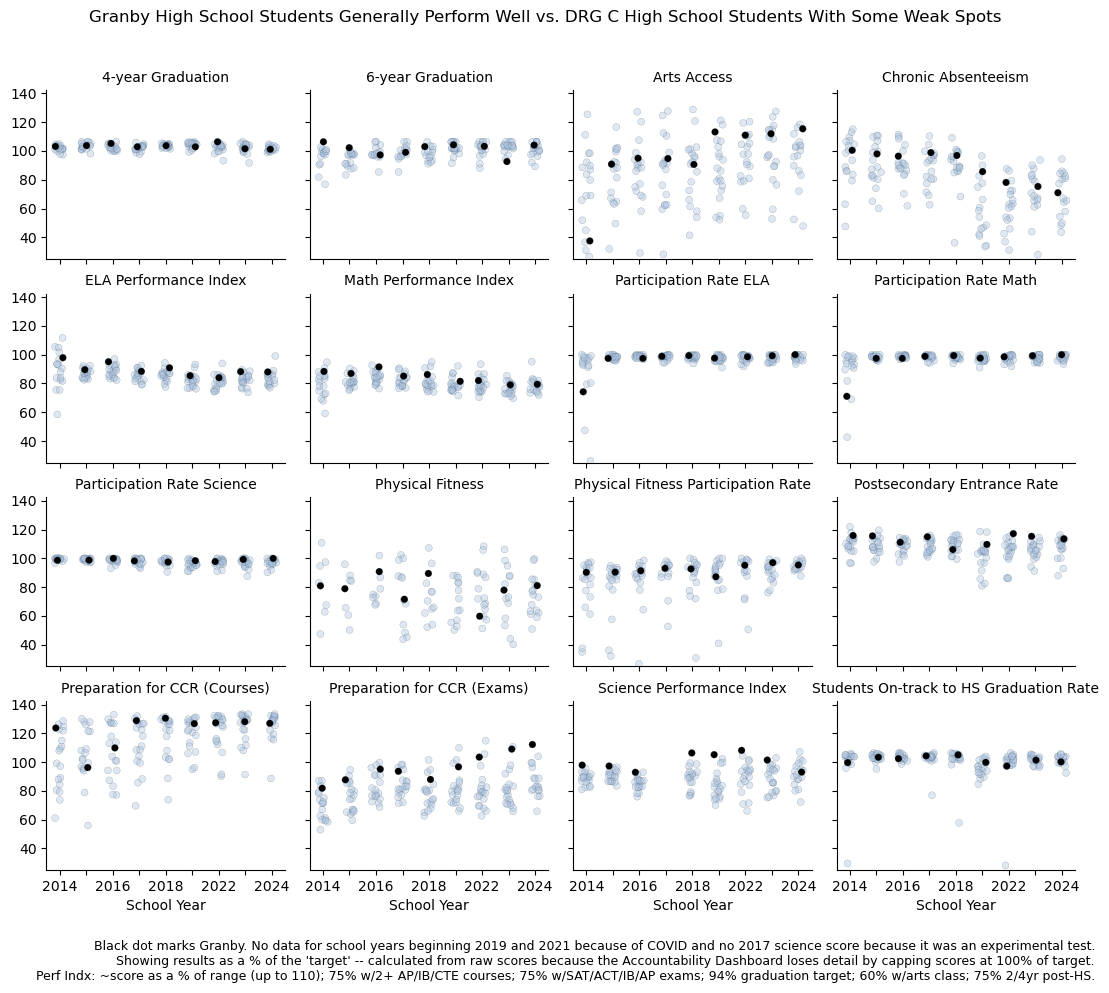

In [25]:
g = sns.catplot(data=school_accountability.query('Needs == "All"').query('`High Grade` == 12').query('`Low Grade` > 8')\
                     .query('~Indicator.str.endswith("Growth")').query('~Indicator.str.startswith("Progress")')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip',  jitter=.18,
                col='Indicator', col_wrap=4, aspect=1.1, legend=False,
                height=2.5, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=25)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle(f"Granby High School Students Generally Perform Well vs. {PEERTEXT} High School Students With Some Weak Spots")
plt.tight_layout()
plt.subplots_adjust(top=.9, bottom=0.12)
line1 = "Black dot marks Granby. No data for school years beginning 2019 and 2021 because of COVID and no 2017 science score because it was an experimental test.\n"
line2 = "Showing results as a % of the 'target' -- calculated from raw scores because the Accountability Dashboard loses detail by capping scores at 100% of target.\n"
line3 = "Perf Indx: ~score as a % of range (up to 110); 75% w/2+ AP/IB/CTE courses; 75% w/SAT/ACT/IB/AP exams; 94% graduation target; 60% w/arts class; 75% 2/4yr post-HS."
g.fig.text(1.0, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/accountability/{PEERVAR}/highschool_overall.png", dpi=200, metadata=png_metadata)

plt.show()

### High School: Not High Needs

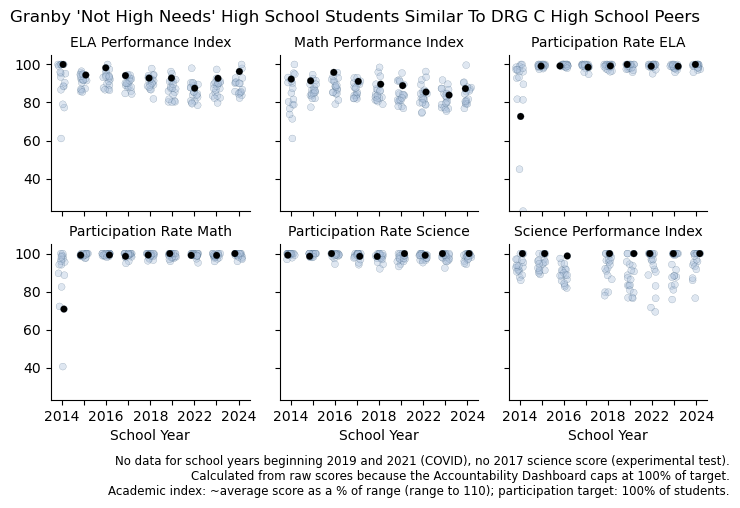

In [45]:
g = sns.catplot(data=school_accountability.query('Needs == "Not High Needs"').query('`High Grade` == 12').query('`Low Grade` > 8')\
                     .query('~Indicator.str.endswith("Growth")')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip',  jitter=.18,
                col='Indicator', col_wrap=3, legend=False,
                height=2.5, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=23)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)

       
g.fig.suptitle(f"Granby 'Not High Needs' High School Students Similar To {PEERTEXT} High School Peers")
plt.subplots_adjust(top=.89, bottom=0.2)
line1 = "No data for school years beginning 2019 and 2021 (COVID), no 2017 science score (experimental test).\n"
line2 = "Calculated from raw scores because the Accountability Dashboard caps at 100% of target.\n"
line3 = "Academic index: ~average score as a % of range (range to 110); participation target: 100% of students."
g.fig.text(1.0, .01, line1 + line2 + line3, ha='right', fontsize=8.5)

plt.savefig(f"./charts/accountability/{PEERVAR}/highschool_not_high_needs.png", dpi=200, metadata=png_metadata)

plt.show()

### High School: High Needs

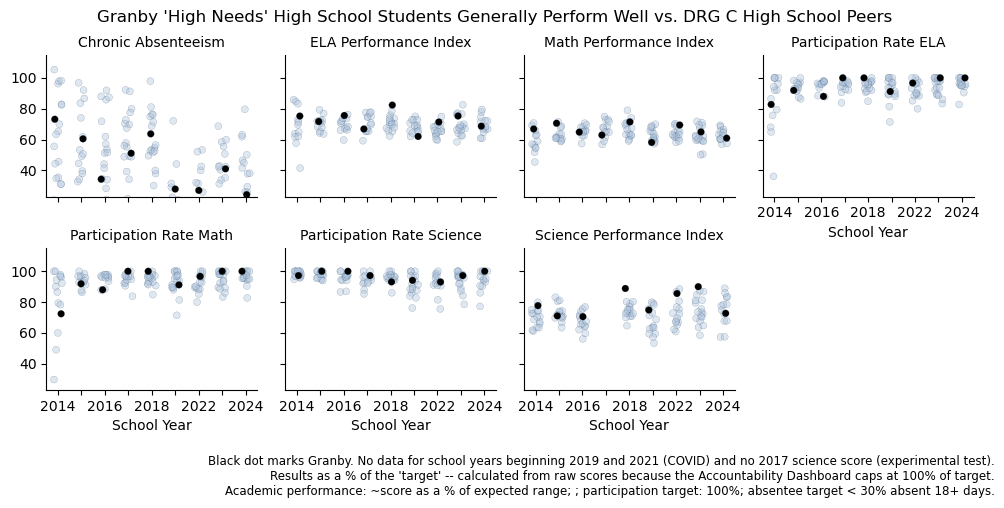

In [47]:
g = sns.catplot(data=school_accountability.query('Needs == "High Needs"').query('`High Grade` == 12').query('`Low Grade` > 8')\
                     .query('~Indicator.str.endswith("Growth")')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip',  jitter=.18,
                col='Indicator', col_wrap=4, legend=False,
                height=2.5, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=23)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)

       
g.fig.suptitle(f"Granby 'High Needs' High School Students Generally Perform Well vs. {PEERTEXT} High School Peers")
plt.tight_layout()
plt.subplots_adjust(top=.89, bottom=0.22)
line1 = "Black dot marks Granby. No data for school years beginning 2019 and 2021 (COVID) and no 2017 science score (experimental test).\n"
line2 = "Results as a % of the 'target' -- calculated from raw scores because the Accountability Dashboard caps at 100% of target.\n"
line3 = "Academic performance: ~score as a % of expected range; ; participation target: 100%; absentee target < 30% absent 18+ days."
g.fig.text(1.0, .01, line1 + line2 + line3, ha='right', fontsize=8.5)
plt.savefig(f"./charts/accountability/{PEERVAR}/highschool_high_needs.png", dpi=200, metadata=png_metadata)

plt.show()

### Middle School: Overall

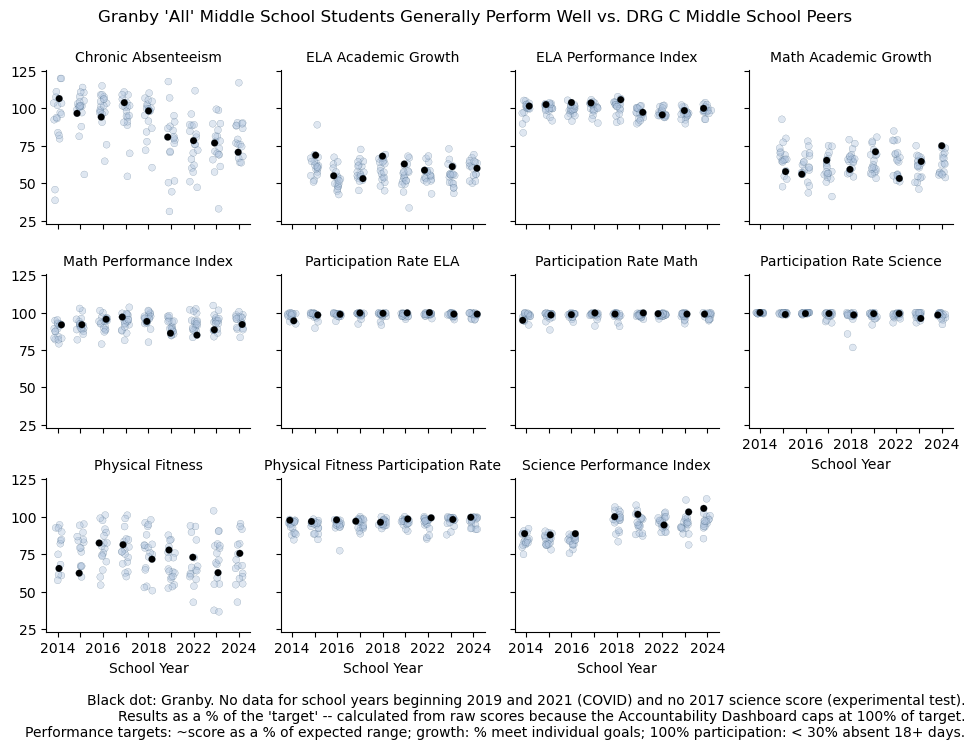

In [62]:
g = sns.catplot(data=school_accountability.query('Needs == "All"').query('`High Grade` == 8').query('`Low Grade` >= 5')\
                     .query('Indicator.str.find("Grad") < 0').query('Indicator.str.find("Arts") < 0')\
                     .query('Indicator.str.find("CCR") < 0').query('Indicator.str.find("Progress") < 0')\
                     .query('Indicator.str.find("Postse") < 0')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip', jitter=.18,
                col='Indicator', col_wrap=4, legend=False,
                height=2.5, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=23)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle(f"Granby 'All' Middle School Students Generally Perform Well vs. {PEERTEXT} Middle School Peers")
plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Black dot: Granby. No data for school years beginning 2019 and 2021 (COVID) and no 2017 science score (experimental test).\n"
line2 = "Results as a % of the 'target' -- calculated from raw scores because the Accountability Dashboard caps at 100% of target.\n"
line3 = "Performance targets: ~score as a % of expected range; growth: % meet individual goals; 100% participation: < 30% absent 18+ days."
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)

plt.savefig(f"./charts/accountability/{PEERVAR}/middleschool_overall.png", dpi=200, metadata=png_metadata)

plt.show()

### Middle School: Not High Needs

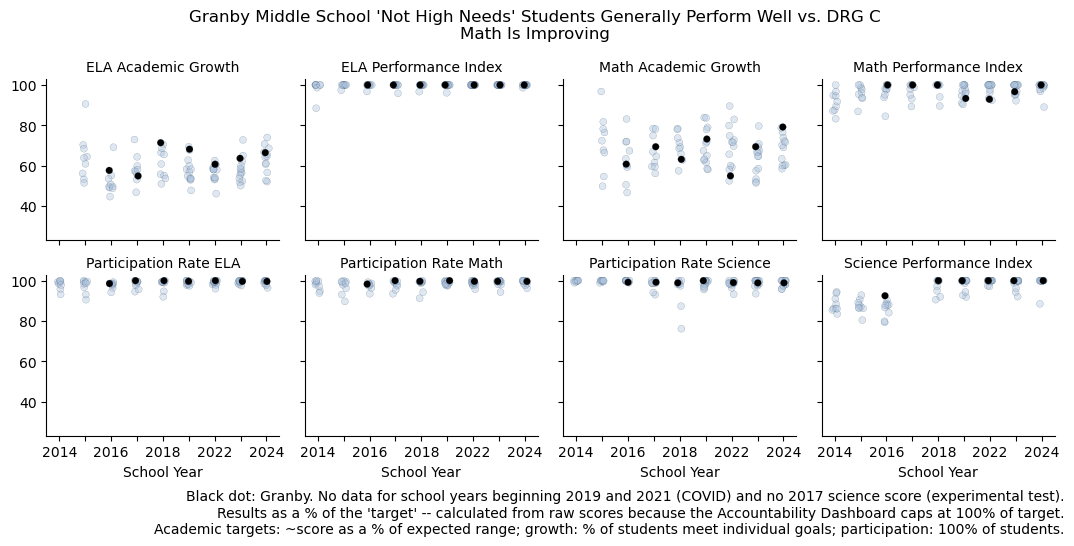

In [63]:
g = sns.catplot(data=school_accountability.query('Needs == "Not High Needs"').query('`High Grade` == 8').query('`Low Grade` == 6')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip',
                col='Indicator', col_wrap=4, legend=False,
                height=2.7, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=23)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle(f"Granby Middle School 'Not High Needs' Students Generally Perform Well vs. {PEERTEXT}\nMath Is Improving")
plt.tight_layout()
plt.subplots_adjust(top=.85, bottom=0.19)
line1 = "Black dot: Granby. No data for school years beginning 2019 and 2021 (COVID) and no 2017 science score (experimental test).\n"
line2 = "Results as a % of the 'target' -- calculated from raw scores because the Accountability Dashboard caps at 100% of target.\n"
line3 = "Academic targets: ~score as a % of expected range; growth: % of students meet individual goals; participation: 100% of students."
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)

plt.savefig(f"./charts/accountability/{PEERVAR}/middleschool_not_high_needs.png", dpi=200, metadata=png_metadata)

plt.show()

### Middle School: High Needs

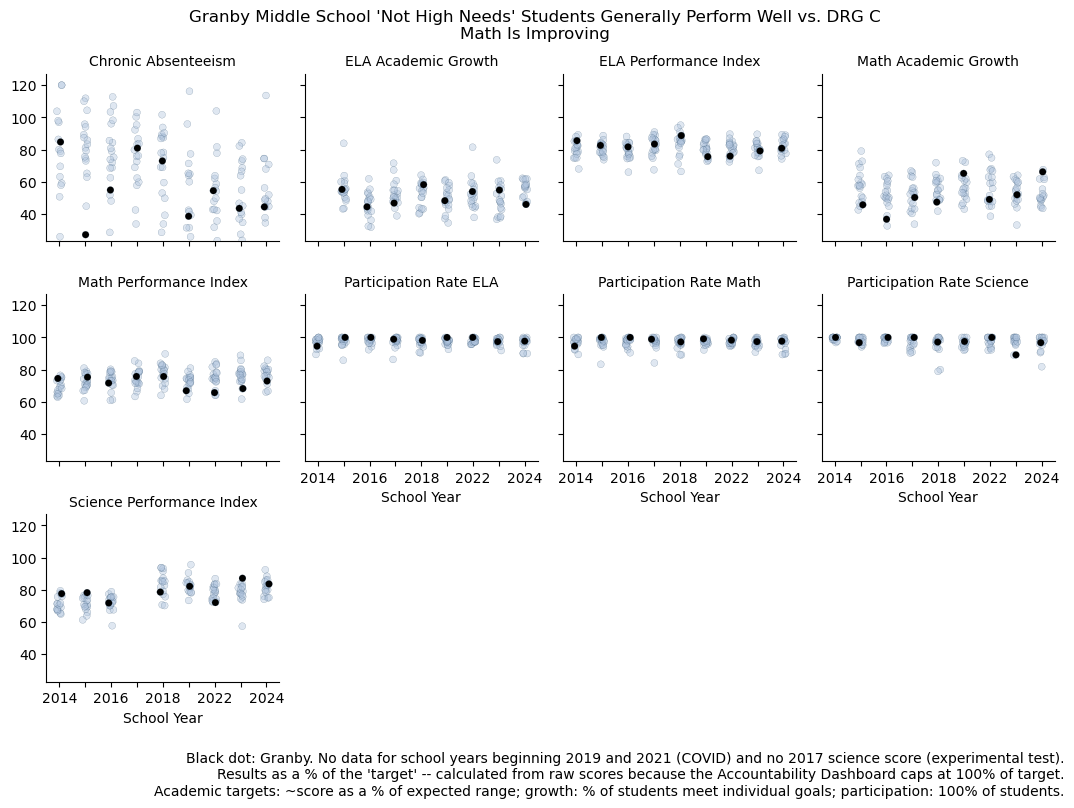

In [64]:
g = sns.catplot(data=school_accountability.query('Needs == "High Needs"').query('`High Grade` == 8').query('`Low Grade` >= 5')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip',
                col='Indicator', col_wrap=4, legend=False,
                height=2.7, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=23)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle(f"Granby Middle School 'Not High Needs' Students Generally Perform Well vs. {PEERTEXT}\nMath Is Improving")
plt.tight_layout()
plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Black dot: Granby. No data for school years beginning 2019 and 2021 (COVID) and no 2017 science score (experimental test).\n"
line2 = "Results as a % of the 'target' -- calculated from raw scores because the Accountability Dashboard caps at 100% of target.\n"
line3 = "Academic targets: ~score as a % of expected range; growth: % of students meet individual goals; participation: 100% of students."
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)

plt.savefig(f"./charts/accountability/{PEERVAR}/middleschool_high_needs.png", dpi=200, metadata=png_metadata)

plt.show()

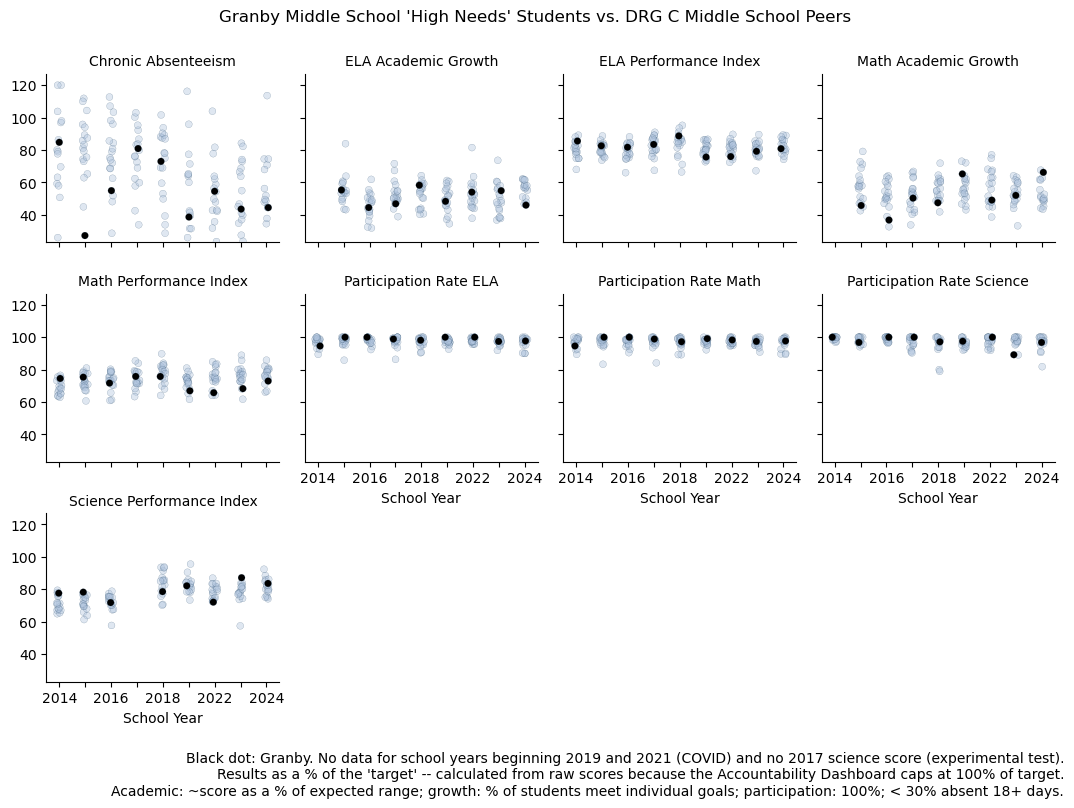

In [65]:
g = sns.catplot(data=school_accountability.query('Needs == "High Needs"').query('`High Grade` == 8').query('`Low Grade` >= 5')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip',
                col='Indicator', col_wrap=4, legend=False,
                height=2.7, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=23)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle(f"Granby Middle School 'High Needs' Students vs. {PEERTEXT} Middle School Peers")
plt.tight_layout()
plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Black dot: Granby. No data for school years beginning 2019 and 2021 (COVID) and no 2017 science score (experimental test).\n"
line2 = "Results as a % of the 'target' -- calculated from raw scores because the Accountability Dashboard caps at 100% of target.\n"
line3 = "Academic: ~score as a % of expected range; growth: % of students meet individual goals; participation: 100%; < 30% absent 18+ days."
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)

plt.savefig(f"./charts/accountability/{PEERVAR}/middleschool_high_needs.png", dpi=200, metadata=png_metadata)

plt.show()

### Elementary: Overall

In [66]:
school_accountability.query('Needs == "High Needs"')['High Grade'].value_counts().sort_index()

High Grade
0        9
1        9
2      558
3      189
4     1098
5     1449
6      549
8     1593
12    1602
Name: count, dtype: int64

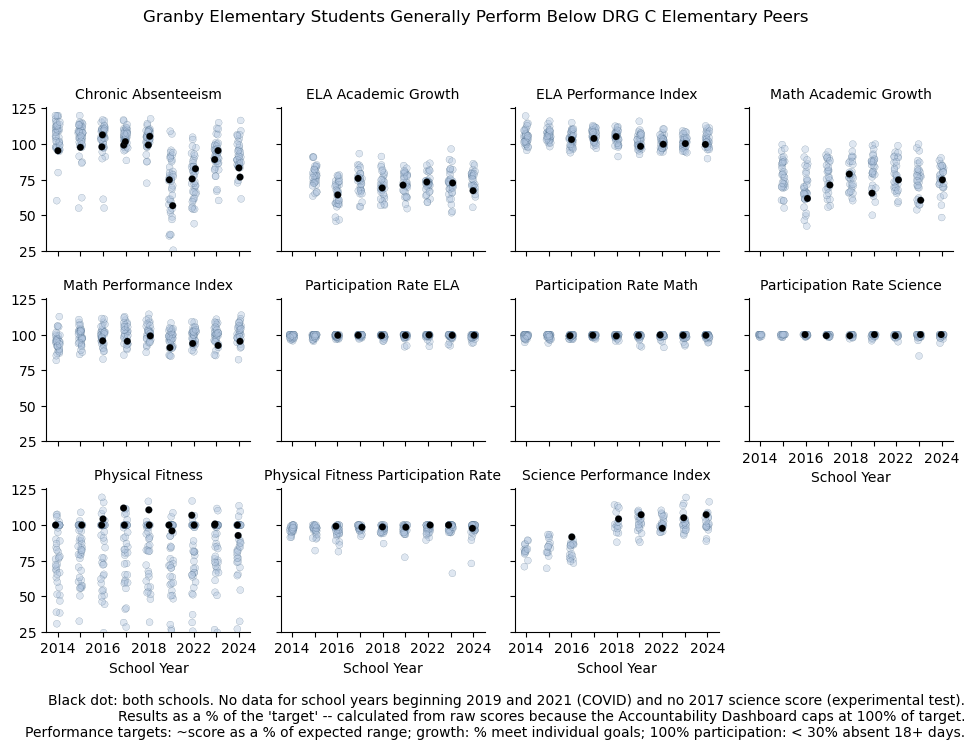

In [70]:
g = sns.catplot(data=school_accountability.query('Needs == "All"').query('`High Grade` <= 5')\
                     .query('Indicator.str.find("Grad") < 0').query('Indicator.str.find("Arts") < 0')\
                     .query('Indicator.str.find("CCR") < 0').query('Indicator.str.find("Progress") < 0')\
                     .query('Indicator.str.find("Postse") < 0')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip', 
                col='Indicator', col_wrap=4, legend=False,
                height=2.5, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=25)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle(f"Granby Elementary Students Generally Perform Below {PEERTEXT} Elementary Peers")
plt.subplots_adjust(top=.85, bottom=0.15)
line1 = "Black dot: both schools. No data for school years beginning 2019 and 2021 (COVID) and no 2017 science score (experimental test).\n"
line2 = "Results as a % of the 'target' -- calculated from raw scores because the Accountability Dashboard caps at 100% of target.\n"
line3 = "Performance targets: ~score as a % of expected range; growth: % meet individual goals; 100% participation: < 30% absent 18+ days."
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)

plt.savefig(f"./charts/accountability/{PEERVAR}/elementary_overall.png", dpi=200, metadata=png_metadata)

plt.show()

### Elementary: Not High Needs

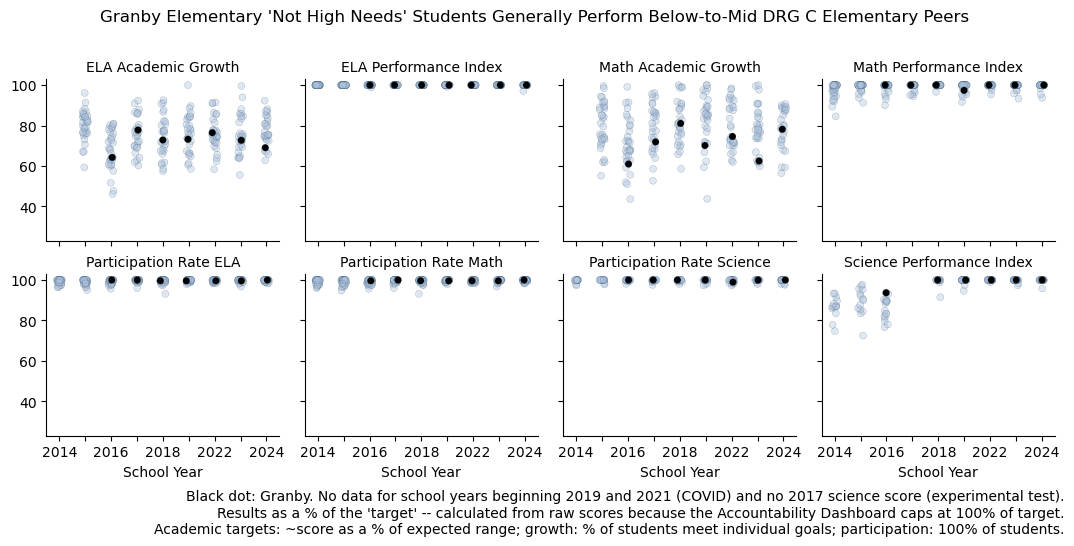

In [71]:
g = sns.catplot(data=school_accountability.query('Needs == "Not High Needs"').query('`High Grade` <= 5')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip',
                col='Indicator', col_wrap=4, legend=False,
                height=2.7, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=23)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle(f"Granby Elementary 'Not High Needs' Students Generally Perform Below-to-Mid {PEERTEXT} Elementary Peers")
plt.tight_layout()
plt.subplots_adjust(top=.85, bottom=0.19)
line1 = "Black dot: Granby. No data for school years beginning 2019 and 2021 (COVID) and no 2017 science score (experimental test).\n"
line2 = "Results as a % of the 'target' -- calculated from raw scores because the Accountability Dashboard caps at 100% of target.\n"
line3 = "Academic targets: ~score as a % of expected range; growth: % of students meet individual goals; participation: 100% of students."
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)

plt.savefig(f"./charts/accountability/{PEERVAR}/elementary_not_high_needs.png", dpi=200, metadata=png_metadata)

plt.show()

### Elementary: High Needs

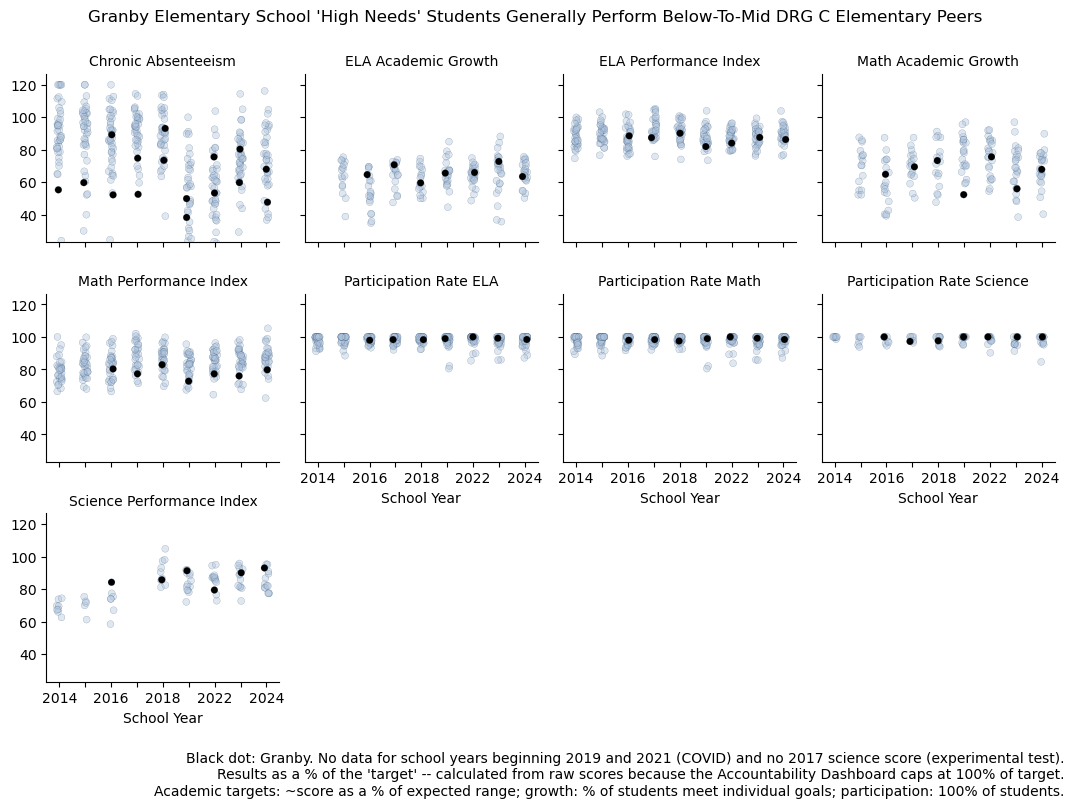

In [73]:
g = sns.catplot(data=school_accountability.query('Needs == "High Needs"').query('`High Grade` <= 5')\
                     .sort_values(by=['Indicator', 'School Year', 'Granby'], ascending=[True, True, False]),
                y='Index', x='School Year', hue='District', kind='strip',
                col='Indicator', col_wrap=4, legend=False,
                height=2.7, palette=school_cols, edgecolor="#2d506eff", linewidth=.11)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(bottom=23)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle(f"Granby Elementary School 'High Needs' Students Generally Perform Below-To-Mid {PEERTEXT} Elementary Peers")
plt.tight_layout()
plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Black dot: Granby. No data for school years beginning 2019 and 2021 (COVID) and no 2017 science score (experimental test).\n"
line2 = "Results as a % of the 'target' -- calculated from raw scores because the Accountability Dashboard caps at 100% of target.\n"
line3 = "Academic targets: ~score as a % of expected range; growth: % of students meet individual goals; participation: 100% of students."
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)

plt.savefig(f"./charts/accountability/{PEERVAR}/elementary_high_needs.png", dpi=200, metadata=png_metadata)

plt.show()

### Performance per Dollar

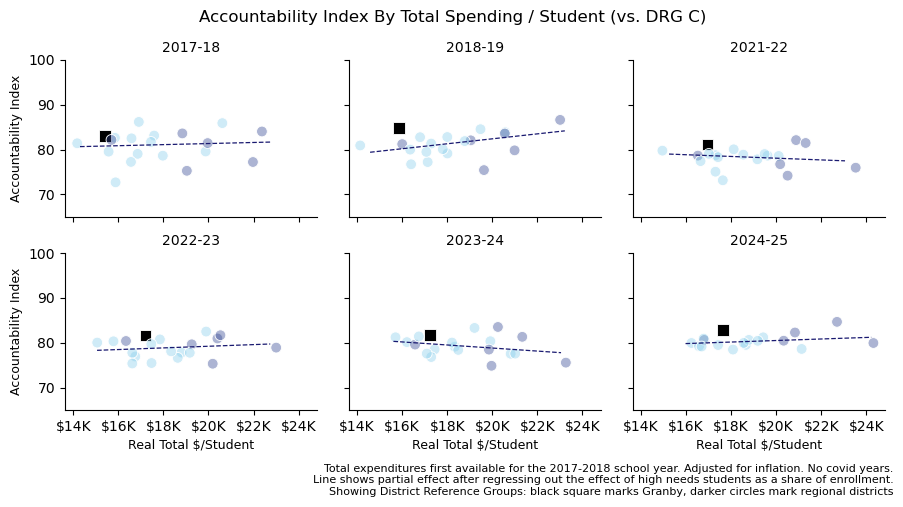

In [35]:

# limit to 12 years
g = sns.relplot(data=peer_combined[~(peer_combined['School Year'].isin(('2012', '2013', '2019', '2020')))],
                x='Real PPE', y='Accountability Index',
               col='Year', col_wrap=3,
               height=2.5, aspect=1.2, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f"Accountability Index By Total Spending / Student (vs. {PEERTEXT})")
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real PPE', y='Accountability Index',
                x_partial='High Needs Students Share of Enrollment',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

#g.set(ylim=(0,.1))

g.set_ylabels("Accountability Index", fontsize=9)
g.set_xlabels("Real Total $/Student", fontsize=9)
for ax in g.axes.flat:
    ax.set_ylim(65,100)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    ax.yaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.88, bottom=0.18)

line1 = "Total expenditures first available for the 2017-2018 school year. Adjusted for inflation. No covid years.\n"
line2 = "Line shows partial effect after regressing out the effect of high needs students as a share of enrollment.\n"
line3 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts"

g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=8)

plt.savefig(f"./charts/accountability/{PEERVAR}/accountability_over_total.png", dpi=200, metadata=png_metadata)

plt.show()

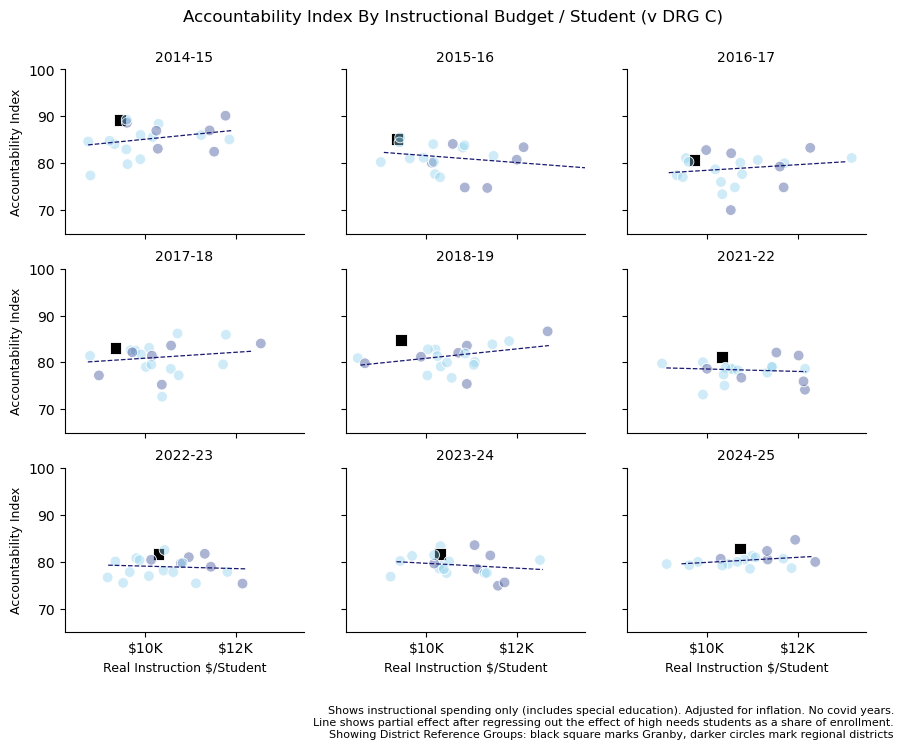

In [36]:
# limit to 12 years
g = sns.relplot(data=peer_instruction[~(peer_instruction['School Year'].isin(('2012', '2013', '2019', '2020')))],
                x='Real PPE', y='Accountability Index',
               col='Year', col_wrap=3,
               height=2.5, aspect=1.2, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f"Accountability Index By Instructional Budget / Student (v {PEERTEXT})")
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real PPE', y='Accountability Index',
                x_partial='High Needs Students Share of Enrollment',
                scatter=False, ci=None, robust=True, 
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set_ylabels("Accountability Index", fontsize=9)
g.set_xlabels("Real Instruction $/Student", fontsize=9)
for ax in g.axes.flat:
    ax.set_ylim(65,100)
    ax.set_xlim(right=13500)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    ax.yaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)

line1 = "Shows instructional spending only (includes special education). Adjusted for inflation. No covid years.\n"
line2 = "Line shows partial effect after regressing out the effect of high needs students as a share of enrollment.\n"
line3 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts"

g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=8)

plt.savefig(f"./charts/accountability/{PEERVAR}/accountability_over_instructional.png", dpi=200, metadata=png_metadata)

plt.show()